# real_groundtruth_multiregion.ipynb

Multi-region version of `real_groundtruth_downscale.ipynb`.

The four-scene protocol is a case study: tens of thousands of HEALPix cells,
but **four patches and one sensor**. This notebook runs the *same seven steps*
on **real Sentinel-2 patches at the 40 region anchors** already used by the
synthetic multi-region validation, so the real-data claim gets the same
statistical treatment as the synthetic one.

Note these are **Sentinel-2** acquisitions, not the Esri textures the
synthetic multi-region validation uses. They reuse only the *site list*.

**Statistical unit is the region.** One patch per region, ten regions per
scene class. The bootstrap below therefore resamples 10 independent values per
class -- a plain bootstrap over regions, not a cluster bootstrap (with a single
patch per region there is no within-region clustering left to absorb).

**Protocol** (identical to the four-scene notebook, see
`tests/real_groundtruth_common_tools.py`):

1. fetch a real, native 10 m Sentinel-2 B04 patch at the region anchor
2. PSF-aware resample the undegraded data to `NATIVE_LEVEL` (20)
3. plain no-PSF NESTED downgrade to `REF_LEVEL` (19) -- **the reference**
4. Gaussian-blur to the coarse effective resolution (FWHM 25 m)
5. point-sample every `BLOCK`-th pixel (20 m observation)
6. PSF-aware resample the coarse samples onto `REF_LEVEL`
7. compare against the reference, cell-for-cell, at `REF_LEVEL`

## Input data

The 40 patches are a **primary input**, archived like every other one:

```text
notebooks/data/multi_patch_sentinel2/region__<class>__<region_id>_data.zarr
```

They are covered by `notebooks/build_data_manifest.py`, so a normal run reads
them offline. Install the bundle with `load_data_in_zenodo.ipynb` first.

If they are not in the published archive yet, build them once with the
acquisition cell below, then rebuild the manifest and publish a new DOI.

**Prerequisite**: `tables/multi_patch_sites.csv` (written by
`multi_patch_latitude_validation.ipynb`) supplies the site list.

## Setup

In [1]:
import sys
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start=None, marker="healpix_resample"):
    """Walk upward until a directory containing `marker` is found."""
    p = Path(start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise RuntimeError(f"Could not locate the repo root above {p}.")


REPO_ROOT = find_repo_root()
MODULE_PATH = REPO_ROOT / "tests" / "real_groundtruth_common_tools.py"
print("module:", MODULE_PATH, "(exists:", MODULE_PATH.exists(), ")")

spec = importlib.util.spec_from_file_location("real_groundtruth_common_tools", MODULE_PATH)
gt = importlib.util.module_from_spec(spec)
spec.loader.exec_module(gt)

gt.describe_config()


module: /home/jovyan/healpix-resample/tests/real_groundtruth_common_tools.py (exists: True )
NATIVE_LEVEL=20: cell size ~= 6.22 m (reference built from real 10 m data, step 2)
REF_LEVEL=19:    cell size ~= 12.44 m (comparison level for every method, vs. 20 m coarse/degraded pixel, step 7)
DEGRADE_PSF_MODE='isotropic': FWHM_x=25.0 m, FWHM_y=25.0 m; isotropic reconstruction FWHM=25.0 m
EDGE_MARGIN_M=200 m excluded from every metric
REFERENCE_MODE='psf_aware', BASELINE_ESTIMAND='cell_average', MAX_ITER=14


## Step 0 -- register the 40 regions

One patch per region, taken at lattice position (1, 1), i.e. the region anchor
itself. The patch is chosen by **position, before any data is fetched or
scored**, so the selection cannot depend on the results.

In [2]:
scenes = gt.load_region_sites()          # patch_row=patch_col=1 by default
print(f"\n{len(scenes)} scenes registered, e.g.:")
for s in scenes[:3]:
    c = gt.region_coordinates[s]
    print(f"  {s:44s} {c['location']:22s} "
          f"lat={c['wgs84']['lat']:7.3f} lon={c['wgs84']['lon']:8.3f}")


Registered 40 regions (4 classes, {'urban': 10, 'water': 10, 'forest': 10, 'agriculture': 10}); 9 candidate patch position(s) each.

40 scenes registered, e.g.:
  region__urban__singapore                     Singapore              lat=  1.290 lon= 103.852
  region__urban__nairobi                       Nairobi, Kenya         lat= -1.286 lon=  36.817
  region__urban__sao_paulo                     Sao Paulo, Brazil      lat=-23.550 lon= -46.633


## Step 1 -- locate the Sentinel-2 patches

Read-only check against the frozen bundle. Nothing is downloaded here.

In [3]:
present = gt.check_region_sites()
available = present.loc[present.present, "scene"].tolist()
display(present[~present.present])
print(f"{len(available)} / {len(present)} region patches usable.")


16/40 region patches present under data/multi_patch_sentinel2.
Missing patches: install the frozen bundle (notebooks/load_data_in_zenodo.ipynb). If they are not in the archive yet, build them once with acquire_region_sites().


,scene,path,present
1,region__agriculture__canterbury,data/multi_patch_sentinel2/region__agriculture...,False
2,region__agriculture__iowa,data/multi_patch_sentinel2/region__agriculture...,False
3,region__agriculture__mato_grosso,data/multi_patch_sentinel2/region__agriculture...,False
5,region__agriculture__pampas,data/multi_patch_sentinel2/region__agriculture...,False
7,region__agriculture__punjab,data/multi_patch_sentinel2/region__agriculture...,False
10,region__forest__amazon,data/multi_patch_sentinel2/region__forest__ama...,False
13,region__forest__borneo,data/multi_patch_sentinel2/region__forest__bor...,False
15,region__forest__congo,data/multi_patch_sentinel2/region__forest__con...,False
17,region__forest__new_zealand,data/multi_patch_sentinel2/region__forest__new...,False
18,region__forest__patagonia,data/multi_patch_sentinel2/region__forest__pat...,False


16 / 40 region patches usable.


### One-off: building the bundle (skip if the archive already has it)

`acquire_region_sites()` is the only network call in this notebook and exists
to *construct* an input bundle, not to run an experiment. Run it once, then
rebuild the manifest and publish a new Zenodo version, then set `OFFLINE` back
to `True` so every later run reads archived copies.

A region with no cloud-free acquisition in `gt.REGION_DATE_WINDOW` fails here
and is skipped downstream -- a data-availability criterion, evaluated long
before any method is scored.

#### Preflight: the `eopf-zarr` backend

Acquisition reads Sentinel-2 from the EOPF STAC through
`engine="eopf-zarr"`, provided by `xarray-eopf`. That package is declared in
the **`notebooks`** pixi environment only, and `pixi.toml` warns that a PyPI
`pyproj` wheel shadowing conda's `libproj` silently *unregisters* the backend
even when the package is installed.

Both failures surface identically, as
`ValueError: unrecognized engine 'eopf-zarr'`, and only after a STAC query --
so check first rather than discovering it on region 1 of 40.

    pixi run -e notebooks jupyter lab

In [4]:
if not gt.check_eopf_engine():
    !pip install -U xarray zarr pyproj pystac-client xarray-eopf


[eopf-zarr] backend registered.


/srv/conda/envs/notebook/lib/python3.13/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


In [5]:
# Leave this cell unexecuted for a normal, offline run.
RUN_ACQUISITION = True

if RUN_ACQUISITION:
    gt.OFFLINE = False
    status = gt.acquire_region_sites()
    gt.OFFLINE = True
    display(status[status.status != "ok"])
    print("\nNow, from the repository root:")
    print("  python notebooks/build_data_manifest.py --doi <new DOI>")
    print("  python notebooks/build_data_manifest.py --check --doi <new DOI>")
    present = gt.check_region_sites()
    available = present.loc[present.present, "scene"].tolist()
else:
    print("Acquisition skipped; using the frozen bundle.")


/srv/conda/envs/notebook/lib/python3.13/site-packages/pystac_client/item_search.py:940: FutureWarning: get_all_items() is deprecated, use item_collection() instead.
  warnings.warn(


[eopf-zarr] backend registered.
[region__agriculture__beauce] cached  <- S2A_MSIL2A_20260812T105651_N0512_R094_T31UCP_20260812T192512  (2026-08-12T10:56:51.024000Z, cloud 0.005677%)
[  1/40] region__agriculture__beauce: ok
[  2/40] [FAIL] region__agriculture__canterbury after 9 position(s): RuntimeError: No items for region__agriculture__canterbury
[  3/40] [FAIL] region__agriculture__iowa after 9 position(s): RuntimeError: No items for region__agriculture__iowa
[  4/40] [FAIL] region__agriculture__mato_grosso after 9 position(s): RuntimeError: No items for region__agriculture__mato_grosso
[region__agriculture__nile_delta] cached  <- S2A_MSIL2A_20241203T083331_N0511_R021_T36RTV_20241203T114054  (2024-12-03T08:33:31.024000Z, cloud 0.005711%)
[  5/40] region__agriculture__nile_delta: ok
[  6/40] [FAIL] region__agriculture__pampas after 9 position(s): RuntimeError: No items for region__agriculture__pampas
[region__agriculture__po_valley] cached  <- S2B_MSIL2A_20260813T101559_N0512_R065_T3

/srv/conda/envs/notebook/lib/python3.13/site-packages/pystac_client/item_search.py:940: FutureWarning: get_all_items() is deprecated, use item_collection() instead.
  warnings.warn(


[ 21/40] [FAIL] region__urban__cape_town after 9 position(s): RuntimeError: No items for region__urban__cape_town
[region__urban__mexico_city] cached  <- S2B_MSIL2A_20250420T165849_N0511_R069_T14QMG_20250420T220222  (2025-04-20T16:58:49.024000Z, cloud 0.063391%)
[ 22/40] region__urban__mexico_city: ok
[ 23/40] [FAIL] region__urban__montreal after 9 position(s): RuntimeError: No items for region__urban__montreal
[ 24/40] [FAIL] region__urban__nairobi after 9 position(s): RuntimeError: No items for region__urban__nairobi
[region__urban__paris] cached  <- S2A_MSIL2A_20260812T105651_N0512_R094_T31UDQ_20260812T192512  (2026-08-12T10:56:51.024000Z, cloud 0.027534%)
[ 25/40] region__urban__paris: ok
[region__urban__reykjavik] cached  <- S2A_MSIL2A_20260818T130311_N0512_R038_T27WVM_20260818T204308  (2026-08-18T13:03:11.024000Z, cloud 9.392069%)
[ 26/40] region__urban__reykjavik: ok
[ 27/40] [FAIL] region__urban__sao_paulo after 9 position(s): RuntimeError: No items for region__urban__sao_paulo

/srv/conda/envs/notebook/lib/python3.13/site-packages/pystac_client/item_search.py:940: FutureWarning: get_all_items() is deprecated, use item_collection() instead.
  warnings.warn(


...

[region__water__lake_victoria] 4 product(s) matched; using S2B_MSIL2A_20241229T080239_N0511_R035_T36MWE_20241229T100143  (2024-12-29T08:02:39.024000Z, cloud 6.834829%)
[region__water__lake_victoria]   others: S2B_MSIL2A_20241229T080239_N0511_R035_T36MWD_20241229T100143, S2B_MSIL2A_20241109T080039_N0511_R035_T36MWD_20241109T101404, S2B_MSIL2A_20241109T080039_N0511_R035_T36MVD_20241109T101404


/srv/conda/envs/notebook/lib/python3.13/site-packages/pystac_client/item_search.py:940: FutureWarning: get_all_items() is deprecated, use item_collection() instead.
  warnings.warn(


[region__water__lake_victoria] 4 product(s) matched; using S2B_MSIL2A_20241229T080239_N0511_R035_T36MWE_20241229T100143  (2024-12-29T08:02:39.024000Z, cloud 6.834829%)
[region__water__lake_victoria]   others: S2B_MSIL2A_20241229T080239_N0511_R035_T36MWD_20241229T100143, S2B_MSIL2A_20241109T080039_N0511_R035_T36MWD_20241109T101404, S2B_MSIL2A_20241109T080039_N0511_R035_T36MVD_20241109T101404
[ 40/40] [FAIL] region__water__lake_victoria after 9 position(s): ValueError: cannot find any grid mapping in dataset

17/40 region patches acquired into data/multi_patch_sentinel2.
Resolved product ids written to tables/real_groundtruth_multiregion_products.csv.
Next: rebuild the manifest and re-publish the archive, then set OFFLINE = True.


,scene,status,scene_class,region_id,patch_id,patch_row,patch_col,attempt,product_id,error
1,region__agriculture__canterbury,failed,agriculture,canterbury,,-1,-1,9,,9 position(s) tried; RuntimeError | last: Runt...
2,region__agriculture__iowa,failed,agriculture,iowa,,-1,-1,9,,9 position(s) tried; RuntimeError | last: Runt...
3,region__agriculture__mato_grosso,failed,agriculture,mato_grosso,,-1,-1,9,,9 position(s) tried; RuntimeError | last: Runt...
5,region__agriculture__pampas,failed,agriculture,pampas,,-1,-1,9,,9 position(s) tried; RuntimeError | last: Runt...
7,region__agriculture__punjab,failed,agriculture,punjab,,-1,-1,9,,9 position(s) tried; RuntimeError | last: Runt...
10,region__forest__amazon,failed,forest,amazon,,-1,-1,9,,9 position(s) tried; RuntimeError | last: Runt...
13,region__forest__borneo,failed,forest,borneo,,-1,-1,9,,9 position(s) tried; RuntimeError | last: Runt...
15,region__forest__congo,failed,forest,congo,,-1,-1,9,,9 position(s) tried; RuntimeError | last: Runt...
17,region__forest__new_zealand,failed,forest,new_zealand,,-1,-1,9,,9 position(s) tried; RuntimeError | last: Runt...
18,region__forest__patagonia,failed,forest,patagonia,,-1,-1,9,,9 position(s) tried; RuntimeError | last: Runt...



Now, from the repository root:
  python notebooks/build_data_manifest.py --doi <new DOI>
  python notebooks/build_data_manifest.py --check --doi <new DOI>
17/40 region patches present under data/multi_patch_sentinel2.
Missing patches: install the frozen bundle (notebooks/load_data_in_zenodo.ipynb). If they are not in the archive yet, build them once with acquire_region_sites().


## Input-quality screen

The STAC cloud filter is a **scene-level** percentage: a granule reported at
8% cloud can still have our 2.56 km patch entirely under a cloud, and a patch
near a granule edge can be mostly no-data. Both would enter the experiment
looking perfectly legitimate.

Every criterion below reads **only the input patch** -- never a reconstruction
or a score -- and runs before any method, so screening cannot favour any
method. Rejections go to `tables/real_groundtruth_multiregion_quality.csv`.

| Criterion | Threshold | Catches |
|---|---|---|
| shape | full `CENTRAL_SIZE` | patch clipped at a granule edge |
| finite fraction | `MIN_FINITE_FRACTION` = 0.99 | no-data holes |
| relative std | `MIN_RELATIVE_STD` = 1e-3 | flat patch, degenerate reference |
| bright fraction | `MAX_BRIGHT_FRACTION` = 0.30 above 0.30 reflectance | cloud or snow over the patch |

In [6]:
usable, quality = gt.screen_region_patches(available)
display(quality[["scene", "shape", "finite_fraction", "relative_std",
                 "bright_fraction", "usable", "flags"]])


/home/jovyan/healpix-resample/tests/real_groundtruth_common_tools.py:1589: RuntimeWarning: Mean of empty slice
  row["finite_fraction"] = float(finite.mean())
/srv/conda/envs/notebook/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/jovyan/healpix-resample/tests/real_groundtruth_common_tools.py:1589: RuntimeWarning: Mean of empty slice
  row["finite_fraction"] = float(finite.mean())
/srv/conda/envs/notebook/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


12/17 patches pass the input-quality screen.

Rejected (input properties only, before any method ran):
  region__agriculture__beauce                  <Flags(allows_duplicate_labels=True)>
  region__agriculture__nile_delta              <Flags(allows_duplicate_labels=True)>
  region__forest__appalachian                  <Flags(allows_duplicate_labels=True)>
  region__forest__canadian_rockies             <Flags(allows_duplicate_labels=True)>
  region__forest__tasmania                     <Flags(allows_duplicate_labels=True)>

Per class among the usable patches:
  agriculture      3
  forest           2
  urban            3
  water            4


,scene,shape,finite_fraction,relative_std,bright_fraction,usable,flags
0,region__agriculture__beauce,256x256,1.000000,0.467564,0.381256,False,bright 38% (cloud/snow?)
1,region__agriculture__nile_delta,256x241,1.000000,0.409450,0.010568,False,too small (<256)
2,region__agriculture__po_valley,256x256,1.000000,0.347414,0.025284,True,
3,region__agriculture__ukraine,256x256,1.000000,0.416515,0.000946,True,
4,region__agriculture__western_australia,256x256,1.000000,0.287339,0.118942,True,
5,region__forest__appalachian,,NaN,NaN,NaN,False,unreadable: KeyError
6,region__forest__black_forest,256x256,1.000000,0.677709,0.000275,True,
7,region__forest__canadian_rockies,0x0,NaN,NaN,NaN,False,too small (<256); no finite pixels
8,region__forest__finland_boreal,256x256,1.000000,0.894233,0.000000,True,
9,region__forest__tasmania,256x0,NaN,NaN,NaN,False,too small (<256); no finite pixels


## Steps 2-7 -- run the protocol on every region

Same code path as the four-scene notebook: `run_all()` per scene, then the
per-region rows are concatenated with their scene class and region id.

In [7]:
metrics, failures = gt.run_multiregion(scenes=usable, force=False)

print()
print(metrics.groupby("scene_class").region_id.nunique().rename("regions").to_string())
display(failures)


[  1/12] region__agriculture__po_valley: 5 rows
[  2/12] region__agriculture__ukraine: 5 rows
[  3/12] region__agriculture__western_australia: 5 rows
[  4/12] region__forest__black_forest: 5 rows
[  5/12] region__forest__finland_boreal: 5 rows
[  6/12] region__urban__mexico_city: 5 rows
[  7/12] region__urban__paris: 5 rows
[  8/12] region__urban__reykjavik: 5 rows
[  9/12] region__water__great_salt_lake: 5 rows
[ 10/12] region__water__lake_constance: 5 rows
[ 11/12] region__water__lake_geneva: 5 rows
[ 12/12] region__water__lake_tahoe: 5 rows

12 regions analysed, 0 failed.

scene_class
agriculture    3
forest         2
urban          3
water          4


""


## How many regions survived, and what that allows

Sentinel-2 availability, not statistics, sets the sample size here. Below
`gt.MIN_REGIONS_FOR_CI` regions a per-class bootstrap interval describes
*which sites happened to be usable*, not the class, so it is suppressed and
the class mean is reported as descriptive only.

In [8]:
availability = gt.region_availability(metrics)
display(availability)


12 regions analysed. Per-class breakdown:
  agriculture      3  <- below MIN_REGIONS_FOR_CI=6, descriptive only
  forest           2  <- below MIN_REGIONS_FOR_CI=6, descriptive only
  urban            3  <- below MIN_REGIONS_FOR_CI=6, descriptive only
  water            4  <- below MIN_REGIONS_FOR_CI=6, descriptive only

Quote the pooled paired_summary() result as the primary statistic; report per-class means as descriptive, without intervals.


,scene_class,n_regions,per_class_ci_reportable
0,agriculture,3,False
1,forest,2,False
2,urban,3,False
3,water,4,False


### Primary statistic: pooled paired comparison

Every region counts once; each competitor is paired against PSF-aware *within
the same region*, so between-site scene variability cancels. The sign test is
exact and distribution-free, which is what this sample size calls for.

**This is the number to quote in the paper.**

In [9]:
pooled = gt.paired_summary(metrics)
display(pooled)

for _, r in pooled.iterrows():
    print(f"vs {r.competitor:20s} {int(r.psf_aware_wins):2d}/{int(r.n_regions):2d}"
          f"   sign-test p={r.sign_test_p:.3g}"
          f"   mean delta={r.mean_delta_rmse:+.5f} "
          f"[{r.delta_ci95_low:+.5f}, {r.delta_ci95_high:+.5f}]")


,competitor,n_regions,psf_aware_wins,win_fraction,sign_test_p,mean_delta_rmse,delta_ci95_low,delta_ci95_high
0,classical_cubic,12,12,1.0,0.000488,0.003681,0.001881,0.005588
1,classical_linear,12,12,1.0,0.000488,0.004891,0.002506,0.007400
2,classical_nearest,12,12,1.0,0.000488,0.004400,0.002281,0.006610
3,richardson_lucy,12,12,1.0,0.000488,0.001962,0.000950,0.003036


vs classical_cubic      12/12   sign-test p=0.000488   mean delta=+0.00368 [+0.00188, +0.00559]
vs classical_linear     12/12   sign-test p=0.000488   mean delta=+0.00489 [+0.00251, +0.00740]
vs classical_nearest    12/12   sign-test p=0.000488   mean delta=+0.00440 [+0.00228, +0.00661]
vs richardson_lucy      12/12   sign-test p=0.000488   mean delta=+0.00196 [+0.00095, +0.00304]


### The pooled result, as a figure

Left: one point per region, PSF-aware against each competitor, log-log with
the 1:1 line -- every point above the line is a region PSF-aware wins. Right:
mean paired difference with bootstrap interval, annotated with wins/n and the
exact sign test.

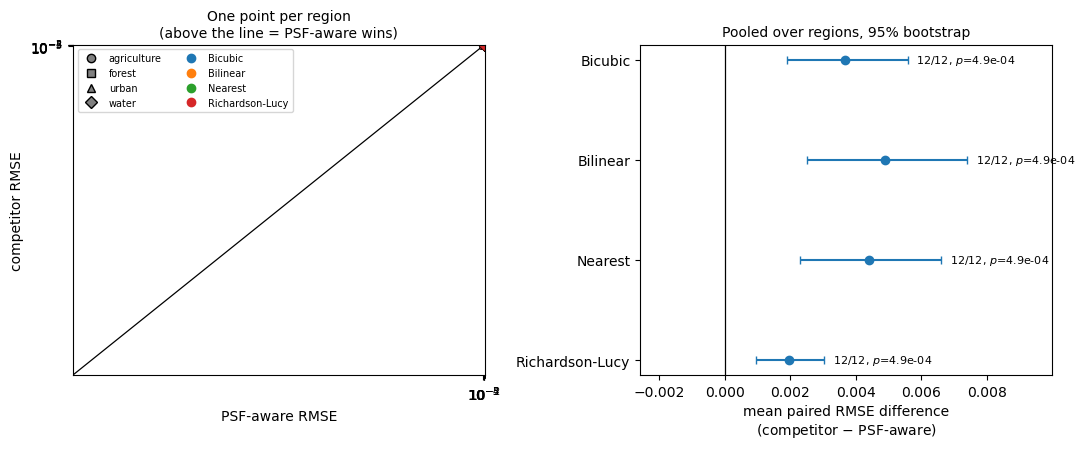

In [10]:
fig = gt.plot_paired_summary(metrics, pooled)


### Secondary: per-class breakdown (descriptive where n is small)

## Region-level aggregation

Per scene class: mean RMSE per method over regions with a percentile bootstrap
interval, and the paired per-region difference against PSF-aware.

In [11]:
summary, comparisons = gt.summarize_multiregion(metrics)
display(summary)


,scene_class,method,n_regions,mean_rmse,rmse_ci95_low,rmse_ci95_high,ci_reportable,between_region_sd
0,agriculture,classical_cubic,3,0.013653,NaN,NaN,False,0.001825
1,agriculture,classical_linear,3,0.015068,NaN,NaN,False,0.001828
2,agriculture,classical_nearest,3,0.014703,NaN,NaN,False,0.001695
3,agriculture,psf_aware,3,0.009802,NaN,NaN,False,0.001621
4,agriculture,richardson_lucy,3,0.011565,NaN,NaN,False,0.002450
5,forest,classical_cubic,2,0.011150,NaN,NaN,False,0.007440
6,forest,classical_linear,2,0.012081,NaN,NaN,False,0.007875
7,forest,classical_nearest,2,0.011753,NaN,NaN,False,0.007610
8,forest,psf_aware,2,0.008221,NaN,NaN,False,0.005615
9,forest,richardson_lucy,2,0.010879,NaN,NaN,False,0.008315


In [12]:
display(comparisons[["scene_class", "competitor", "n_regions",
                     "mean_delta_rmse_competitor_minus_matched",
                     "delta_ci95_low", "delta_ci95_high",
                     "matched_win_fraction"]])

print("win fraction 1.0 everywhere:", bool((comparisons.matched_win_fraction == 1).all()))
print("every paired interval excludes zero:", bool((comparisons.delta_ci95_low > 0).all()))


,scene_class,competitor,n_regions,mean_delta_rmse_competitor_minus_matched,delta_ci95_low,delta_ci95_high,matched_win_fraction
0,agriculture,classical_cubic,3,0.003851,0.003578,0.004093,1.0
1,forest,classical_cubic,2,0.002929,0.001639,0.004219,1.0
2,urban,classical_cubic,3,0.008631,0.007222,0.009416,1.0
3,water,classical_cubic,4,0.000217,0.000060,0.000375,1.0
4,agriculture,classical_linear,3,0.005267,0.004928,0.005510,1.0
5,forest,classical_linear,2,0.003860,0.002262,0.005458,1.0
6,urban,classical_linear,3,0.011329,0.009361,0.012551,1.0
7,water,classical_linear,4,0.000298,0.000075,0.000520,1.0
8,agriculture,classical_nearest,3,0.004902,0.004626,0.005089,1.0
9,forest,classical_nearest,2,0.003532,0.002121,0.004943,1.0


win fraction 1.0 everywhere: True
every paired interval excludes zero: True


## Paper table

In [13]:
table = gt.format_multiregion_table(summary, comparisons)
display(table)


,Scene class,Regions,PSF-aware RMSE,Nearest-neighbor RMSE,Nearest-neighbor delta,Nearest-neighbor delta lo,Nearest-neighbor delta hi,Nearest-neighbor win,Bilinear RMSE,Bilinear delta,...,Bicubic RMSE,Bicubic delta,Bicubic delta lo,Bicubic delta hi,Bicubic win,Richardson-Lucy RMSE,Richardson-Lucy delta,Richardson-Lucy delta lo,Richardson-Lucy delta hi,Richardson-Lucy win
0,agriculture,3,0.009802,0.014703,0.004902,0.004626,0.005089,1.0,0.015068,0.005267,...,0.013653,0.003851,0.003578,0.004093,1.0,0.011565,0.001763,0.001202,0.002715,1.0
1,forest,2,0.008221,0.011753,0.003532,0.002121,0.004943,1.0,0.012081,0.003860,...,0.011150,0.002929,0.001639,0.004219,1.0,0.010879,0.002658,0.000748,0.004567,1.0
2,urban,3,0.032045,0.042023,0.009978,0.008229,0.011059,1.0,0.043374,0.011329,...,0.040676,0.008631,0.007222,0.009416,1.0,0.036199,0.004154,0.002888,0.005351,1.0
3,water,4,0.000996,0.001270,0.000274,0.000066,0.000481,1.0,0.001294,0.000298,...,0.001214,0.000217,0.000060,0.000375,1.0,0.001114,0.000118,0.000032,0.000204,1.0


## Figure -- per-class RMSE with bootstrap intervals

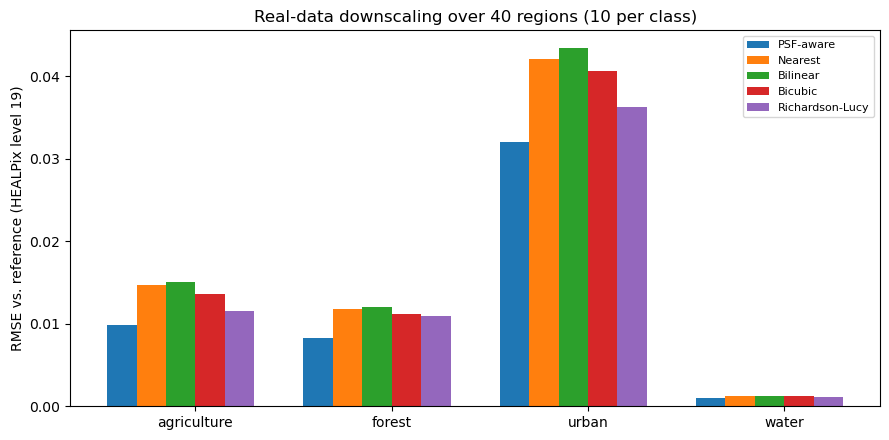

In [14]:
methods = ["psf_aware", "classical_nearest", "classical_linear",
           "classical_cubic", "richardson_lucy"]
labels = {"psf_aware": "PSF-aware", "classical_nearest": "Nearest",
          "classical_linear": "Bilinear", "classical_cubic": "Bicubic",
          "richardson_lucy": "Richardson-Lucy"}
classes = sorted(summary.scene_class.unique())

fig, ax = plt.subplots(figsize=(9, 4.5))
width = 0.15
x = np.arange(len(classes))
for i, m in enumerate(methods):
    sub = summary[summary.method == m].set_index("scene_class")
    vals = [sub.loc[c, "mean_rmse"] if c in sub.index else np.nan for c in classes]
    lo = [sub.loc[c, "mean_rmse"] - sub.loc[c, "rmse_ci95_low"] if c in sub.index else 0 for c in classes]
    hi = [sub.loc[c, "rmse_ci95_high"] - sub.loc[c, "mean_rmse"] if c in sub.index else 0 for c in classes]
    ax.bar(x + (i - len(methods) / 2) * width, vals, width,
           yerr=[lo, hi], capsize=2, label=labels[m])
ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel(f"RMSE vs. reference (HEALPix level {gt.REF_LEVEL})")
ax.set_title("Real-data downscaling over 40 regions (10 per class)")
ax.legend(fontsize=8)
fig.tight_layout()
gt.FIG_DIR.mkdir(exist_ok=True)
fig.savefig(gt.FIG_DIR / "real_groundtruth_multiregion_rmse.pdf", dpi=200)


## Width-mismatch control (real-data analogue of the +-50% arms)

The degradation stays at 25 m; only the **assumed** reconstruction width
changes. Note the asymmetry that makes this informative: only PSF-aware and
Richardson--Lucy use the assumed width, so a width error costs exactly the two
response-modelling methods and leaves the geometric baselines untouched.

Run on the four benchmark scenes first (cheap); pass `scenes=available` to
repeat it over all 40 regions.

In [15]:
df_wide   = gt.run_width_mismatch(scale=1.5)   # overestimated response
df_narrow = gt.run_width_mismatch(scale=0.5)   # underestimated response
df_matched = gt.run_all(force=False)

comp = (df_matched[["scene", "method", "rmse"]]
        .merge(df_wide[["scene", "method", "rmse"]], on=["scene", "method"],
               suffixes=("_matched", "_plus50"))
        .merge(df_narrow[["scene", "method", "rmse"]].rename(columns={"rmse": "rmse_minus50"}),
               on=["scene", "method"]))
comp["plus50_pct"] = 100 * (comp.rmse_plus50 - comp.rmse_matched) / comp.rmse_matched
comp["minus50_pct"] = 100 * (comp.rmse_minus50 - comp.rmse_matched) / comp.rmse_matched
display(comp)


,scene,method,rmse_matched,rmse_plus50,rmse_minus50,plus50_pct,minus50_pct
0,urban,psf_aware,0.027182,0.034689,0.034920,2.761613e+01,2.846893e+01
1,urban,classical_nearest,0.036431,0.036431,0.036431,1.718831e-06,2.012047e-06
2,urban,classical_linear,0.037736,0.037736,0.037736,1.887712e-06,2.045964e-06
3,urban,classical_cubic,0.035285,0.035285,0.035285,2.154325e-06,2.254309e-06
4,urban,richardson_lucy,0.035386,0.038192,0.038949,7.929240e+00,1.006748e+01
5,water,psf_aware,0.008972,0.011061,0.011291,2.328780e+01,2.584451e+01
6,water,classical_nearest,0.011714,0.011714,0.011714,1.871467e-06,2.331894e-06
7,water,classical_linear,0.012077,0.012077,0.012077,1.715305e-06,2.338208e-06
8,water,classical_cubic,0.011308,0.011308,0.011308,1.746946e-06,2.348571e-06
9,water,richardson_lucy,0.010370,0.011526,0.011756,1.114975e+01,1.336225e+01


## Notes

- Every result-changing setting (`REF_LEVEL`, `BLOCK`, `RECON_FWHM_M`,
  `MAX_ITER`, `REFERENCE_MODE`, `BASELINE_ESTIMAND`, degradation mode) is
  encoded in the cache and CSV filenames via `gt._cache_suffix()`, so variants
  never overwrite each other or the four-scene result the paper's Table VI is
  built from.
- `gt.run_multiregion()` skips a region only when its patch is missing or its
  reference is degenerate. Both criteria are evaluated before any method is
  scored.
- To rerun everything from scratch, pass `force=True`; otherwise cached
  intermediate `.npz` files are reused.

## Publish the paper assets

`tex/figures/` and `tex/tables/` are separate copies of what this notebook
writes. Publishing them here keeps the compiled paper in step with the last
run instead of relying on a manual copy.

In [ ]:
# Publish notebook outputs into tex/figures and tex/tables.
#
# Loaded by file path rather than by `import`: the module lives in the same
# repository as this notebook, but a checkout that has not been synced yet
# would otherwise fail with a bare ModuleNotFoundError at the very end of a
# long run. Here a missing file says so, and says where it should be.
import importlib.util
from pathlib import Path


def _repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for c in (p, *p.parents):
        if (c / "healpix_resample").is_dir() and (c / "notebooks").is_dir():
            return c
    raise RuntimeError(f"healpix-resample checkout not found above {p}")


_pub = _repo_root() / "notebooks" / "publish_paper_assets.py"
if not _pub.exists():
    print(f"publish_paper_assets.py not found at {_pub}\n"
          f"Nothing was published: tex/figures and tex/tables still hold the\n"
          f"previous run's assets. Sync the repository, then re-run this cell,\n"
          f"or from the repository root:\n"
          f"    python notebooks/publish_paper_assets.py")
else:
    _spec = importlib.util.spec_from_file_location("publish_paper_assets", _pub)
    _mod = importlib.util.module_from_spec(_spec)
    _spec.loader.exec_module(_mod)
    _mod.publish()
